# Step 1: Load Training, Validation and Test Data

Load processed datasets for model training and evaluation.

In [17]:
# X (features)
X_train = pd.read_csv('../data/X_train.csv')
X_val   = pd.read_csv('../data/X_val.csv')
X_test  = pd.read_csv('../data/X_test.csv')

# Drop leakage feature ONLY from X
X_train = X_train.drop(columns=["isFlaggedFraud"], errors="ignore")
X_val   = X_val.drop(columns=["isFlaggedFraud"], errors="ignore")
X_test  = X_test.drop(columns=["isFlaggedFraud"], errors="ignore")

# y (target) → NO DROP
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_val   = pd.read_csv('../data/y_val.csv').values.ravel()
y_test  = pd.read_csv('../data/y_test.csv').values.ravel()

In [18]:
X_train.head(10)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,308,260485.2300,32371.0000,292856.2300,4633560.3500,4373075.1200,-260485.2300,-260485.2300,False,False,False,False
1,16,1387060.1900,432673.7800,0.0000,0.0000,1033440.6200,432673.7800,1033440.6200,False,False,False,True
2,254,1140661.9800,59947.0000,0.0000,15000.8500,1155662.8300,59947.0000,1140661.9800,False,False,False,True
3,380,169390.3900,80047.1000,249437.4900,1467039.6600,1297649.2700,-169390.3900,-169390.3900,False,False,False,False
4,40,4867.2600,5989226.1400,5994093.4000,1609385.2800,1604518.0200,-4867.2600,-4867.2600,False,False,False,False
5,186,149232.2500,48976.0000,0.0000,74673.9500,223906.2100,48976.0000,149232.2600,True,False,False,False
6,231,110195.9100,0.0000,0.0000,194576.2900,304772.1900,0.0000,110195.9000,True,False,False,False
7,201,52697.7200,0.0000,0.0000,1490655.1100,1543352.8300,0.0000,52697.7200,True,False,False,False
8,258,80358.7000,102034.7200,182393.4200,498718.3000,418359.6000,-80358.7000,-80358.7000,False,False,False,False
9,371,213680.2300,8436.0000,0.0000,596399.9800,810080.2200,8436.0000,213680.2400,True,False,False,False


# Step 2: Model Training

Train XGBoost model for fraud detection.

In [19]:
# import 'Pandas'
import pandas as pd

# import 'Numpy'
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# import 'Seaborn'
import seaborn as sns

# to suppress warnings
from warnings import filterwarnings
filterwarnings('ignore')

# to display the float values upto 4 decimal places
pd.options.display.float_format = '{:.4f}'.format

# import train-test split
from sklearn.model_selection import train_test_split

# import StandardScaler to perform scaling
from sklearn.preprocessing import StandardScaler

# import various functions from sklearn
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV

# import the functions for visualizing the decision tree
from IPython.display import Image

# setting the random seed
# DO NOT CHANGE
np.random.seed(1)

from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,roc_curve,roc_auc_score,classification_report,confusion_matrix,cohen_kappa_score,roc_curve,roc_auc_score

In [20]:
from sklearn.model_selection import train_test_split
# Normal skmodel
def skmodel(model,x,y,test_size):

    xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=test_size,random_state=42)
    model=model.fit(xtrain,ytrain)

    # Prediction
    ypred_train=model.predict(xtrain)
    ypred_test=model.predict(xtest)

    yproba_train=model.predict_proba(xtrain)[:,1]
    yproba_test=model.predict_proba(xtest)[:,1]

    return model,ytrain,ytest,ypred_train,ypred_test,yproba_train,yproba_test
    
    
# Normal Logistic Model 
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

def statsmodel(x, y, test_size,th=0.5):

    # Split data
    xtrain, xtest, ytrain, ytest = train_test_split(
        x, y, test_size=test_size, random_state=42
    )

    # Add constant
    xtrain_c = sm.add_constant(xtrain)
    xtest_c = sm.add_constant(xtest)

    # Fit logit model
    model = sm.Logit(ytrain, xtrain_c).fit(disp=False)

    # Predictions (probabilities)
    yproba_train = model.predict(xtrain_c)
    yproba_test  = model.predict(xtest_c)

    # Convert probabilities to 0/1
    ypred_train = (yproba_train >= th).astype(int)
    ypred_test  = (yproba_test  >= th).astype(int)

    # Return list exactly like your code
    return model, ytrain, ytest, ypred_train, ypred_test, yproba_train,yproba_test

# Metrics
d=pd.DataFrame(columns=['Model_Name','Accuracy','Re-call','Precision','F1-Score','Roc-Auc-Score','Kappa'])
def metrics(model,actual,predicted,proba=None):

    acc=accuracy_score(actual,predicted)
    rec=recall_score(actual,predicted)
    pre=precision_score(actual,predicted)
    f1=f1_score(actual,predicted)
    cohen=cohen_kappa_score(actual,predicted)
    auc=roc_auc_score(actual,proba) if proba is not None else None

    r=pd.DataFrame()
    r['Model_Name']=[model]
    r['Accuracy']=[acc]
    r['Re-call']=[rec]
    r['Precision']=[pre]
    r['F1-Score']=[f1]
    r['Kappa']=[cohen]
    r['Roc-Auc-Score']=[auc]

    global d
    d=pd.concat([d,r],ignore_index=True)

# Classfication report
  
    print(classification_report(actual,predicted))
    print(confusion_matrix(actual,predicted))
    return d

from sklearn.feature_selection import RFE

def run_rfe(estimator, x, y, n_features=5):
    rfe = RFE(estimator=estimator, n_features_to_select=n_features)
    rfe.fit(X, y)
    selected_features = rfe.get_feature_names_out(x.columns).tolist()

    return selected_features


def fi(model,x,n_features):
    r=pd.DataFrame()
    r['Features']=x.columns
    r['FI_value']=model.feature_importances_
    s= r.sort_values(by='FI_value',ascending=False).head(n_features)
    return s


# Roc Curve Graph
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_plain(ytest, yproba_test):
    fpr, tpr, _ = roc_curve(ytest, yproba_test)
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1])
    plt.show()


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

              precision    recall  f1-score   support

           0       0.95      0.96      0.95   1328167
           1       0.96      0.95      0.95   1332821

    accuracy                           0.95   2660988
   macro avg       0.95      0.95      0.95   2660988
weighted avg       0.95      0.95      0.95   2660988

[[1269162   59005]
 [  62200 1270621]]


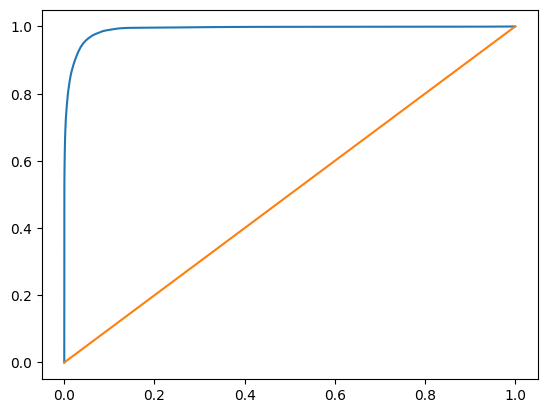

In [24]:
model, ytrain, ytest, ypred_train, ypred_test, yproba_train, yproba_test = skmodel(
    LogisticRegression(max_iter=1000), X_train, y_train, 0.3
)

metrics("Logistic", ytest, ypred_test, yproba_test)
plot_roc_plain(ytest, yproba_test)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1328167
           1       0.96      1.00      0.98   1332821

    accuracy                           0.98   2660988
   macro avg       0.98      0.98      0.98   2660988
weighted avg       0.98      0.98      0.98   2660988

[[1277119   51048]
 [   6049 1326772]]


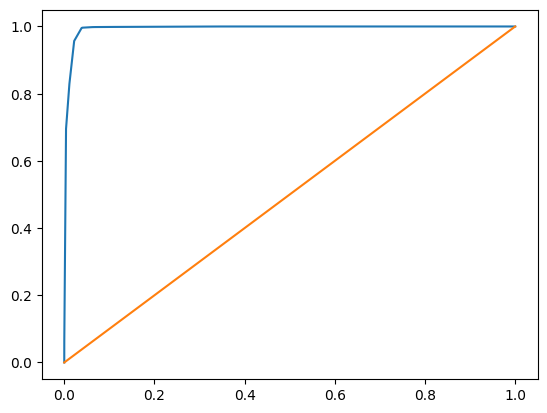

In [25]:
model, ytrain, ytest, ypred_train, ypred_test, yproba_train, yproba_test = skmodel(
    DecisionTreeClassifier(max_depth=5), X_train, y_train, 0.3
)

metrics("DecisionTree", ytest, ypred_test, yproba_test)
plot_roc_plain(ytest, yproba_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1328167
           1       1.00      1.00      1.00   1332821

    accuracy                           1.00   2660988
   macro avg       1.00      1.00      1.00   2660988
weighted avg       1.00      1.00      1.00   2660988

[[1327738     429]
 [     72 1332749]]


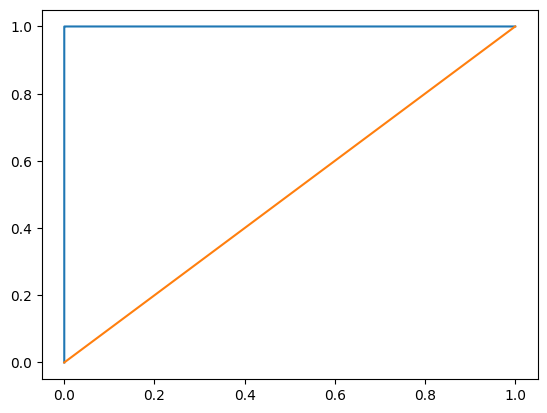

In [26]:
model, ytrain, ytest, ypred_train, ypred_test, yproba_train, yproba_test = skmodel(
    RandomForestClassifier(n_estimators=100), X_train, y_train, 0.3
)

metrics("RandomForest", ytest, ypred_test, yproba_test)
plot_roc_plain(ytest, yproba_test)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1328167
           1       0.99      1.00      0.99   1332821

    accuracy                           0.99   2660988
   macro avg       0.99      0.99      0.99   2660988
weighted avg       0.99      0.99      0.99   2660988

[[1310030   18137]
 [   4657 1328164]]


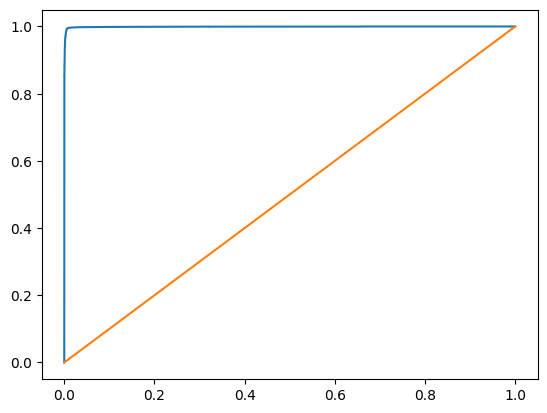

In [27]:
model, ytrain, ytest, ypred_train, ypred_test, yproba_train, yproba_test = skmodel(
    GradientBoostingClassifier(), X_train, y_train, 0.3
)

metrics("GradientBoost", ytest, ypred_test, yproba_test)
plot_roc_plain(ytest, yproba_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1328167
           1       1.00      1.00      1.00   1332821

    accuracy                           1.00   2660988
   macro avg       1.00      1.00      1.00   2660988
weighted avg       1.00      1.00      1.00   2660988

[[1326240    1927]
 [    704 1332117]]


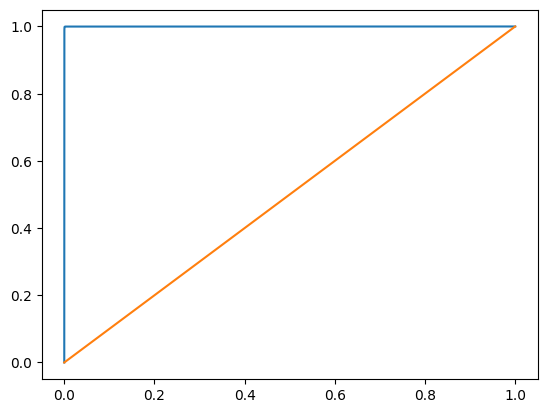

In [21]:
model, ytrain, ytest, ypred_train, ypred_test, yproba_train, yproba_test = skmodel(
    XGBClassifier(eval_metric='logloss'), X_train, y_train, 0.3
)

metrics("XGBoost", ytest, ypred_test, yproba_test)
plot_roc_plain(ytest, yproba_test)

In [22]:
best_model=model

In [ ]:
model, ytrain, ytest, ypred_train, ypred_test, yproba_train, yproba_test = statsmodel(
    X_train, y_train, 0.3
)

metrics("Stats_Logit", ytest, ypred_test, yproba_test)
plot_roc_plain(ytest, yproba_test)

In [29]:
d

,Model_Name,Accuracy,Re-call,Precision,F1-Score,Roc-Auc-Score,Kappa
0,Logistic,0.9545,0.9533,0.9556,0.9545,0.9914,0.9089
1,DecisionTree,0.9785,0.9955,0.9630,0.9789,0.9939,0.9571
2,RandomForest,0.9998,0.9999,0.9997,0.9998,1.0000,0.9996
3,GradientBoost,0.9914,0.9965,0.9865,0.9915,0.9992,0.9829
4,XGBoost,0.9990,0.9995,0.9985,0.9990,1.0000,0.9980


# Model Performance Inference

| Model Name      | Performance Summary | Strengths | Weakness | Final Verdict |
|----------------|-------------------|----------|----------|--------------|
| Logistic       | Lowest performance among all models | Simple, interpretable | Lower accuracy & recall | Not suitable for fraud detection |
| Decision Tree  | Moderate performance | Easy to understand, fast | Overfitting risk, lower precision than ensemble models | Not preferred |
| Random Forest  | Excellent performance (near perfect) | High accuracy, high recall, stable | Slightly heavy model | Strong candidate |
| Gradient Boost | Good performance but lower than RF/XGB | Handles complex patterns | Slightly lower recall & precision | Secondary option |
| XGBoost        | Best overall balanced performance | High precision, recall, ROC-AUC, robust | Slightly complex | ✅ Final Selected Model |

# Step: Feature Importance

Identify most important features influencing fraud prediction.

In [23]:
fi(model, X_train, 10)

,Features,FI_value
6,balance_diff_orig,0.4374
3,newbalanceOrig,0.2130
10,type_PAYMENT,0.1064
11,type_TRANSFER,0.0827
1,amount,0.0602
5,newbalanceDest,0.0362
8,type_CASH_OUT,0.0332
2,oldbalanceOrg,0.0104
7,balance_diff_dest,0.0092
0,step,0.0060


# Feature Importance Inference

| Feature Name         | Importance Level | Interpretation | Business Insight |
|---------------------|-----------------|---------------|------------------|
| balance_diff_orig   | Very High       | Difference in sender balance before and after transaction | Strong indicator of suspicious activity |
| newbalanceOrig      | High            | Remaining balance after transaction | Helps detect abnormal balance drops |
| type_PAYMENT        | Medium          | Payment transaction type | Certain transaction types are safer |
| type_TRANSFER       | Medium          | Transfer transactions | Highly associated with fraud cases |
| amount              | Medium          | Transaction amount | Large or unusual amounts indicate risk |
| newbalanceDest      | Low-Medium      | Receiver balance after transaction | Helps track abnormal credit patterns |
| type_CASH_OUT       | Low-Medium      | Cash-out transactions | Frequently used in fraud scenarios |
| isFlaggedFraud      | Low             | System flagged fraud | Already known fraud indicator |
| oldbalanceOrg       | Low             | Initial sender balance | Less predictive alone |
| balance_diff_dest   | Low             | Difference in receiver balance | Weak standalone signal |

# Step: Feature Selection using RFE

Select top features for better model performance.

In [11]:
def run_rfe(estimator, x, y, n_features=5):
    rfe = RFE(estimator=estimator, n_features_to_select=n_features)
    rfe.fit(x, y)

    selected_features = x.columns[rfe.support_].tolist()
    return selected_features

In [41]:
from sklearn.ensemble import RandomForestClassifier

selected_features = run_rfe(RandomForestClassifier(), X_train, y_train, 10)
selected_features

# Step: Threshold Optimization

Adjust decision threshold to improve fraud detection performance.

In [24]:
threshold = 0.6

y_pred_custom = (yproba_test > threshold).astype(int)

metrics("XGBoost_Threshold_0.6", ytest, y_pred_custom, yproba_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1328167
           1       1.00      1.00      1.00   1332821

    accuracy                           1.00   2660988
   macro avg       1.00      1.00      1.00   2660988
weighted avg       1.00      1.00      1.00   2660988

[[1326562    1605]
 [    943 1331878]]


,Model_Name,Accuracy,Re-call,Precision,F1-Score,Roc-Auc-Score,Kappa
0,XGBoost,0.9990,0.9995,0.9986,0.9990,1.0000,0.9980
1,XGBoost_Threshold_0.6,0.9990,0.9993,0.9988,0.9990,1.0000,0.9981


# Step: Final Model Selection

Select the best performing model based on ROC-AUC and Precision-Recall.

<Axes: xlabel='0'>

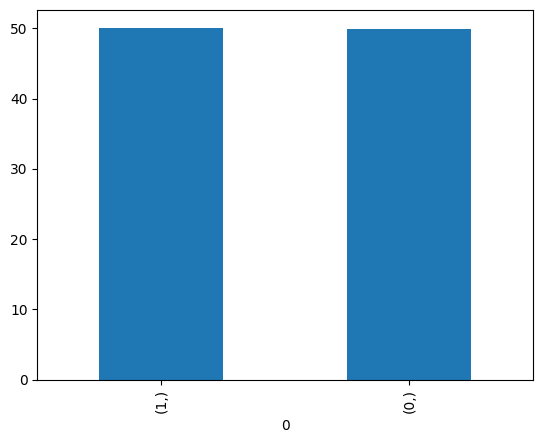

In [13]:
(pd.DataFrame(y_train).value_counts(normalize=True)*100).plot(kind='bar')

In [25]:
d.sort_values(by='Roc-Auc-Score', ascending=False)

,Model_Name,Accuracy,Re-call,Precision,F1-Score,Roc-Auc-Score,Kappa
0,XGBoost,0.9990,0.9995,0.9986,0.9990,1.0000,0.9980
1,XGBoost_Threshold_0.6,0.9990,0.9993,0.9988,0.9990,1.0000,0.9981


# Step: Final Model Training

Train the best selected model on full training data.

In [16]:
from xgboost import XGBClassifier

best_model = XGBClassifier(tree_method='hist')

best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Step: Final Evaluation on Test Data

In [8]:
y_test_prob = best_model.predict_proba(X_test)[:,1]
y_test_pred = (y_test_prob > 0.3).astype(int)

from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))
print(classification_report(y_test, y_test_pred))

ROC-AUC: 0.999453095811194
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.28      0.99      0.43      1232

    accuracy                           1.00    954393
   macro avg       0.64      0.99      0.72    954393
weighted avg       1.00      1.00      1.00    954393



# Why ROC-AUC is Given Higher Priority in Fraud Detection

| Aspect | Reason | Explanation |
|--------|--------|-------------|
| Class Imbalance | Handles imbalance effectively | Fraud datasets are highly imbalanced, so accuracy becomes misleading |
| Threshold Independent | Evaluates across all thresholds | ROC-AUC measures performance without fixing a decision threshold |
| Ranking Ability | Evaluates probability ranking | Checks how well the model ranks fraud cases higher than normal cases |
| Stability | More consistent metric | Unlike precision/recall, it is not sensitive to threshold selection |
| Business Relevance | Useful for risk scoring | Helps in ranking transactions based on fraud risk |


# Practical Interpretation in This Project

- The dataset is highly imbalanced  
- Accuracy (~99%) can be misleading  
- ROC-AUC ≈ 1.0 indicates excellent class separation  
- The model can distinguish fraud vs non-fraud very effectively  

## Key Insight

ROC-AUC confirms that the model has learned strong fraud detection patterns rather than just predicting the majority class.

# Important Observation

Even though ROC-AUC is very high:

- Precision (fraud class) is low (~0.29)
- Recall (fraud class) is very high (~0.99)

## Interpretation

- The model is catching almost all fraud cases (high recall)  
- But it is also generating many false positives (low precision)  

## Conclusion

- High ROC-AUC does not mean perfect performance  
- Threshold tuning is required to balance precision and recall  

# Final Decision Logic

We prioritize ROC-AUC because:

- It measures overall model capability  
- It is independent of threshold  
- It works well for imbalanced datasets  

However, final model selection also considers:

- Recall → to minimize missed fraud cases  
- Precision → to reduce false alarms  

ROC-AUC is preferred because it evaluates the model’s ability to distinguish between classes across all thresholds, which is critical in imbalanced fraud detection problems.”

# Step: Validation vs Test Performance Comparison

Compare model performance on validation and test datasets using ROC curves and metrics.

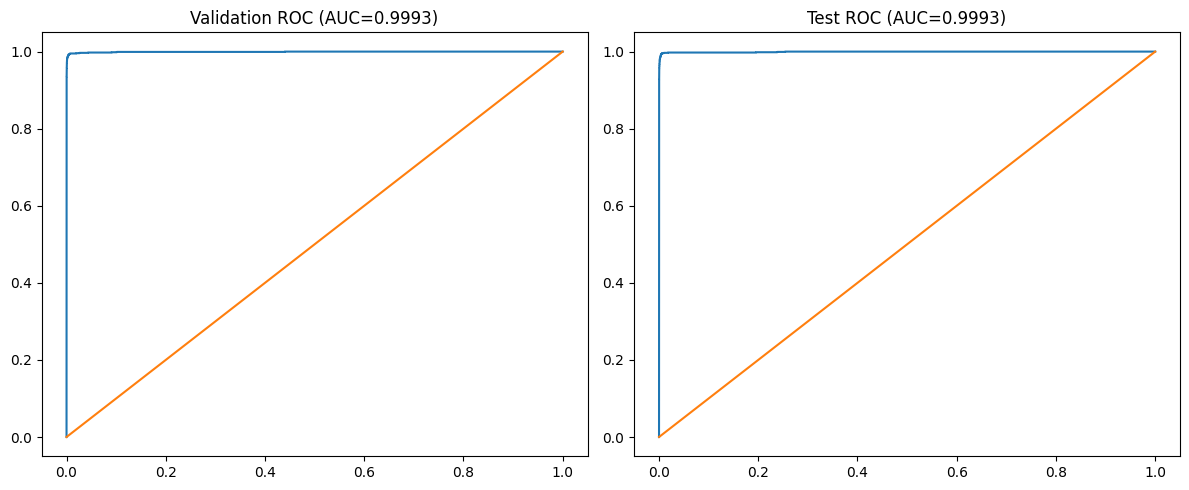

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Validation predictions
y_val_prob = best_model.predict_proba(X_val)[:,1]

# Test predictions
y_test_prob = best_model.predict_proba(X_test)[:,1]

# ROC values
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

# AUC
auc_val = roc_auc_score(y_val, y_val_prob)
auc_test = roc_auc_score(y_test, y_test_prob)

plt.rcParams['figure.figsize'] = (12,5)

fig, axes = plt.subplots(1,2)

# Validation ROC
axes[0].plot(fpr_val, tpr_val)
axes[0].plot([0,1],[0,1])
axes[0].set_title(f'Validation ROC (AUC={auc_val:.4f})')

# Test ROC
axes[1].plot(fpr_test, tpr_test)
axes[1].plot([0,1],[0,1])
axes[1].set_title(f'Test ROC (AUC={auc_test:.4f})')

plt.tight_layout()
plt.show()

# ROC Curve Analysis (Validation vs Test)

## Observation

- Both Validation and Test ROC curves are almost identical  
- ROC-AUC ≈ 0.9993 for both datasets  
- Curve is very close to top-left corner  

## Interpretation

- Model has excellent class separation capability  
- Very strong ability to distinguish fraud vs non-fraud  
- No significant overfitting observed (since both curves match)  

## Conclusion

- Model generalizes well from validation to unseen test data  
- ROC-AUC confirms high model reliability  

# Step: Metrics Comparison (Validation vs Test)

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold = 0.3

y_val_pred = (y_val_prob > threshold).astype(int)
y_test_pred = (y_test_prob > threshold).astype(int)

import pandas as pd

comparison = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "Precision": [
        precision_score(y_val, y_val_pred),
        precision_score(y_test, y_test_pred)
    ],
    "Recall": [
        recall_score(y_val, y_val_pred),
        recall_score(y_test, y_test_pred)
    ],
    "F1 Score": [
        f1_score(y_val, y_val_pred),
        f1_score(y_test, y_test_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_val_prob),
        roc_auc_score(y_test, y_test_prob)
    ]
})

comparison

,Dataset,Precision,Recall,F1 Score,ROC-AUC
0,Validation,0.2909,0.9878,0.4494,0.9993
1,Test,0.2907,0.9878,0.4492,0.9993


# Step: Risk Score Distribution

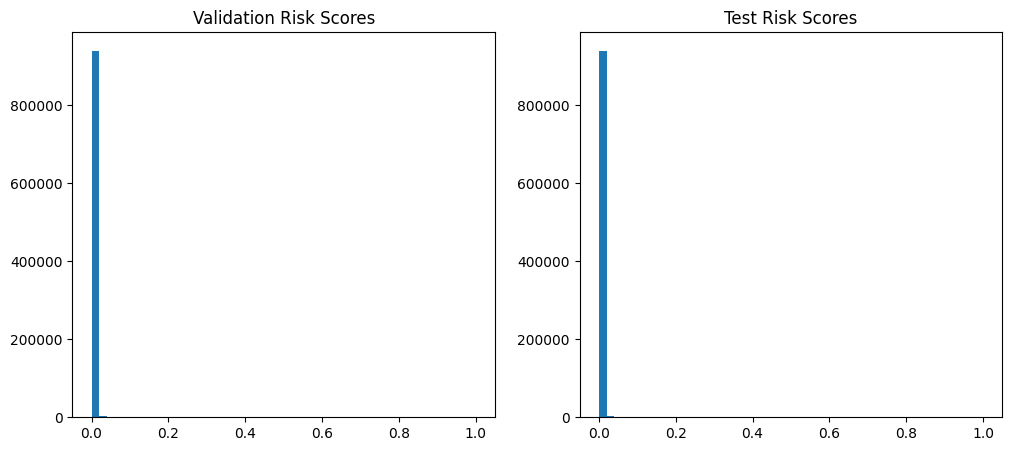

In [22]:
plt.rcParams['figure.figsize'] = (12,5)

fig, axes = plt.subplots(1,2)

axes[0].hist(y_val_prob, bins=50)
axes[0].set_title("Validation Risk Scores")

axes[1].hist(y_test_prob, bins=50)
axes[1].set_title("Test Risk Scores")

plt.show()

# Risk Score Distribution Analysis

## Observation

- Majority of predictions are concentrated near 0  
- Very few high-risk (fraud) probability values  
- Similar distribution for validation and test  

## Interpretation

- Dataset is highly imbalanced (very few fraud cases)  
- Model assigns low probability to most transactions (correct behavior)  
- High-risk scores are rare but significant  

## Conclusion

- Model is consistent across validation and test datasets  
- Risk scoring is realistic and aligned with real-world fraud patterns  

# Step: Model Explainability using SHAP

In [23]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train.sample(1000))

# SHAP Summary Plot

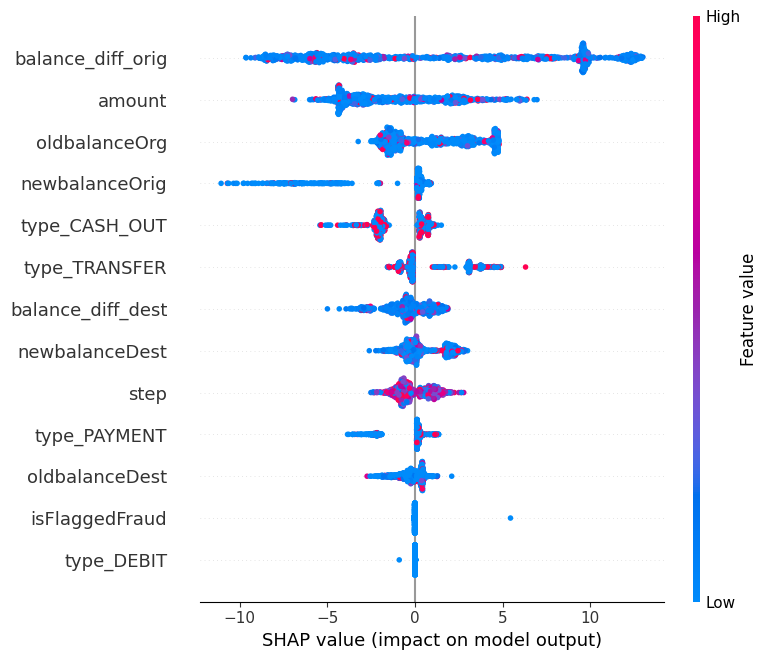

In [24]:
shap.summary_plot(shap_values, X_train.sample(1000))

# SHAP Explainability Analysis

## Observation

- Top features:
  - balance_diff_orig
  - amount
  - oldbalanceOrg
  - newbalanceOrig
- Clear spread of SHAP values across features  

## Interpretation

- Balance-related features have the highest impact on predictions  
- Higher feature values (red) push prediction towards fraud  
- Lower values (blue) push towards non-fraud  

## Key Insight

- Model is learning behavioral transaction patterns  
- Engineered features contribute more than raw features  

## Conclusion

- Model decisions are interpretable and aligned with domain knowledge  
- SHAP confirms model is not acting as a black box  

# Step: Save Artifacts for Streamlit Application

In [25]:
import joblib

# Save model
joblib.dump(best_model, '../models/fraud_model.pkl')

# Save features
joblib.dump(X_train.columns.tolist(), '../models/features.pkl')

# Save threshold
joblib.dump(0.3, '../models/threshold.pkl')

# Save sample data for UI testing
X_test.sample(100).to_csv('../data/sample_input.csv', index=False)

# Step: Create Folder for Saving Plots

Create a directory to store all visualization outputs.

In [26]:
import os

os.makedirs('../outputs', exist_ok=True)

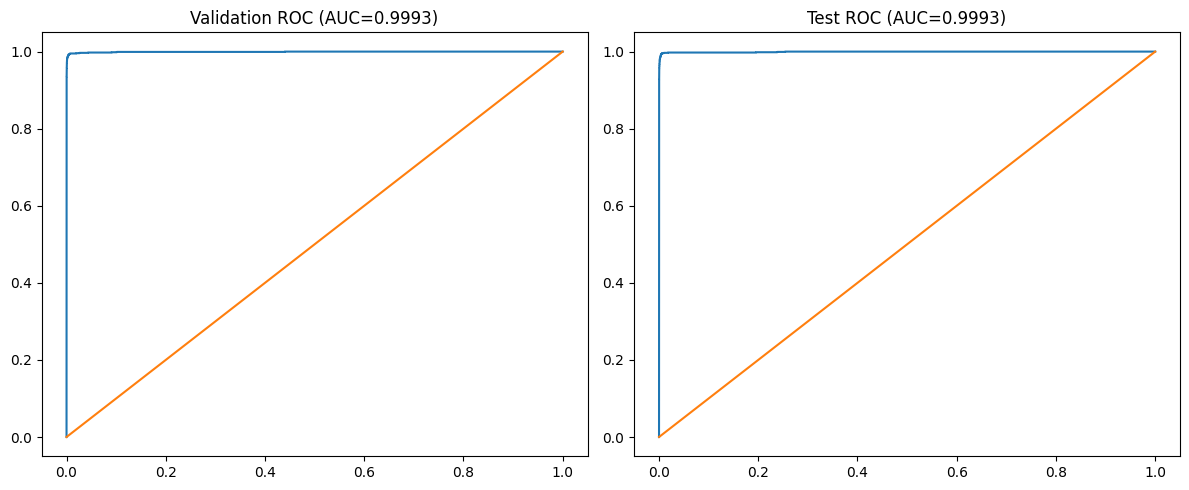

In [27]:
plt.rcParams['figure.figsize'] = (12,5)

fig, axes = plt.subplots(1,2)

axes[0].plot(fpr_val, tpr_val)
axes[0].plot([0,1],[0,1])
axes[0].set_title(f'Validation ROC (AUC={auc_val:.4f})')

axes[1].plot(fpr_test, tpr_test)
axes[1].plot([0,1],[0,1])
axes[1].set_title(f'Test ROC (AUC={auc_test:.4f})')

plt.tight_layout()
plt.savefig('../outputs/roc_comparison.png')
plt.show()

# Step: Save Metrics Comparison Plot

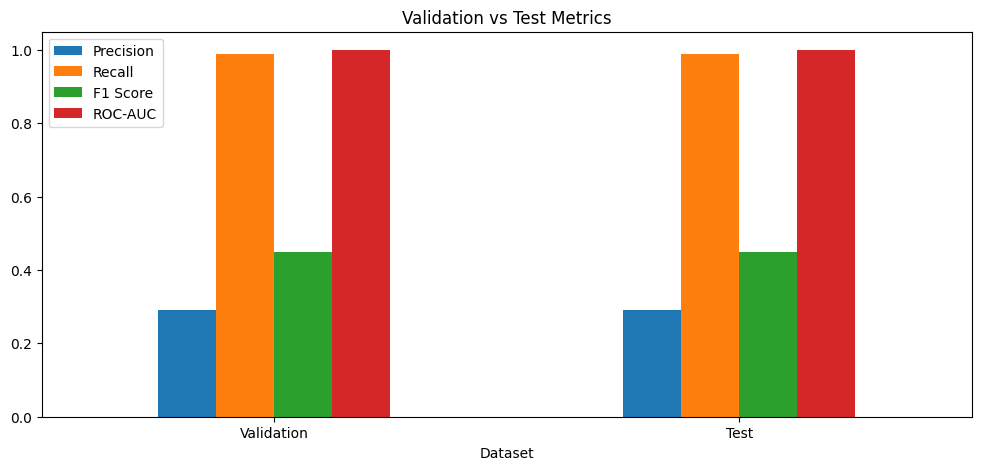

In [33]:
comparison.set_index('Dataset').plot(kind='bar')

plt.title("Validation vs Test Metrics")
plt.xticks(rotation=0)

plt.savefig('../outputs/metrics_comparison.png')
plt.show()

# Metrics Comparison (Validation vs Test)

## Observation

- Precision is low (~0.29) in both datasets  
- Recall is very high (~0.99)  
- F1-score is moderate (~0.45)  
- ROC-AUC is near perfect (~1.0)  

## Interpretation

- Model captures almost all fraud cases (high recall)  
- But generates many false positives (low precision)  
- Performance is consistent across validation and test  

## Business Insight

- High recall is critical → fraud should not be missed  
- Low precision means more alerts → needs optimization  

## Conclusion

- Model is effective but requires threshold tuning  
- Trade-off between precision and recall must be balanced  

# Step: Save Risk Distribution Plot

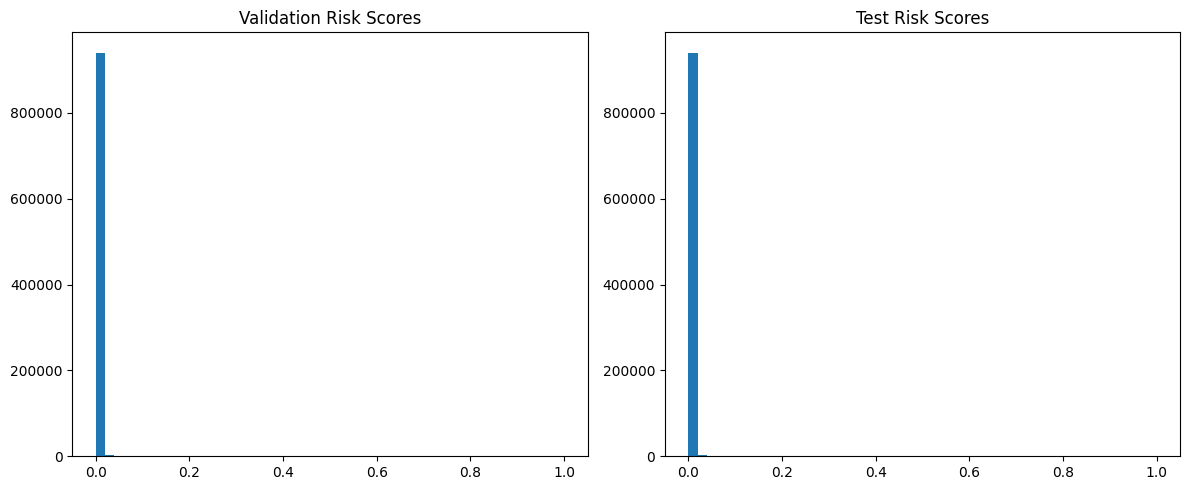

In [32]:
plt.rcParams['figure.figsize'] = (12,5)

fig, axes = plt.subplots(1,2)

axes[0].hist(y_val_prob, bins=50)
axes[0].set_title("Validation Risk Scores")

axes[1].hist(y_test_prob, bins=50)
axes[1].set_title("Test Risk Scores")

plt.tight_layout()
plt.savefig('../outputs/risk_distribution.png')
plt.show()

# Step: Save SHAP Summary Plot

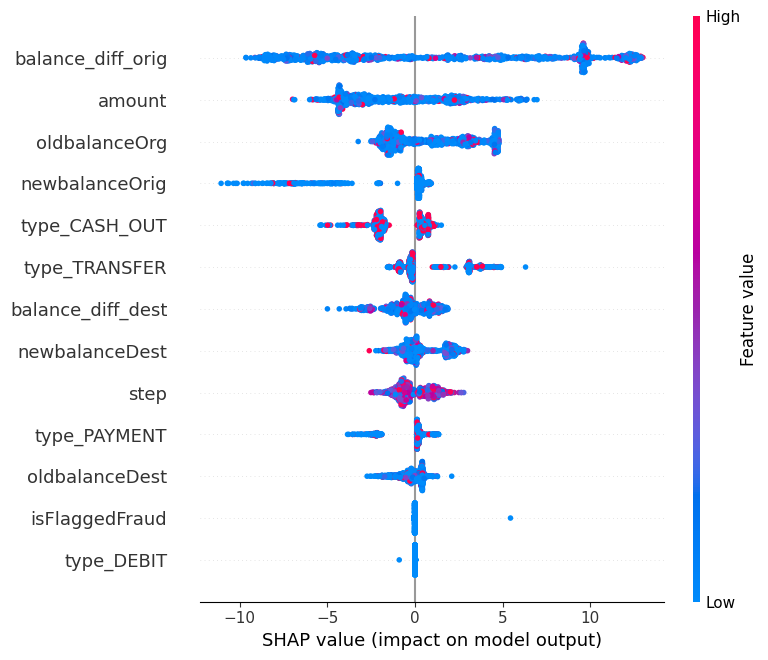

In [30]:
shap.summary_plot(shap_values, X_train.sample(1000), show=False)

plt.savefig('../outputs/shap_summary.png', bbox_inches='tight')
plt.show()